In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
image_folder = '/content/drive/MyDrive/Radiography/images' #path to folder containing images
df_path = "/content/drive/MyDrive/Radiography/df_final.pkl"
chexnet_weights = '/content/drive/MyDrive/Copy of brucechou1983_CheXNet_Keras_0.3.0_weights.h5'

In [ ]:
!pip install imgaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.3 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib #for saving model files as pkl files
import os
import seaborn as sns
import cv2
import imgaug.augmenters as iaa
sns.set(palette='muted',style='white')
import tensorflow as tf
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D, Input, Embedding, LSTM,Dot,Reshape,Concatenate,BatchNormalization, GlobalMaxPooling2D, Dropout, Add
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import sentence_bleu #bleu score
tf.compat.v1.enable_eager_execution()
import os
import math

In [ ]:
df = pd.read_pickle(df_path)
col = ['image_1','image_2','impression','xml file name']
df = df[col].copy()
#path
df['image_1'] = df['image_1'].apply(lambda row: os.path.join(image_folder,row)) #https://stackoverflow.com/a/61880790
df['image_2'] = df['image_2'].apply(lambda row: os.path.join(image_folder,row))

df['impression_final'] = '<CLS> ' + df.impression + ' <END>'
df['impression_ip'] = '<CLS> ' + df.impression
df['impression_op'] = df.impression + ' <END>'
print(df.shape)
df.head(2)

(3820, 7)


,image_1,image_2,impression,xml file name,impression_final,impression_ip,impression_op
0,/content/drive/MyDrive/Radiography/images/CXR3...,/content/drive/MyDrive/Radiography/images/CXR3...,no acute cardiopulmonary findings .,3745.xml,<CLS> no acute cardiopulmonary findings . <END>,<CLS> no acute cardiopulmonary findings .,no acute cardiopulmonary findings . <END>
1,/content/drive/MyDrive/Radiography/images/CXR3...,/content/drive/MyDrive/Radiography/images/CXR3...,no acute cardiopulmonary abnormality .,3749.xml,<CLS> no acute cardiopulmonary abnormality . <...,<CLS> no acute cardiopulmonary abnormality .,no acute cardiopulmonary abnormality . <END>


In [ ]:
df['impression'].value_counts()

,count
impression,
no acute cardiopulmonary abnormality .,320
no active disease .,130
no acute cardiopulmonary findings .,126
no acute cardiopulmonary disease .,126
no acute cardiopulmonary abnormalities .,122
no acute disease .,109
no evidence of active disease .,91
no acute cardiopulmonary abnormality . .,90
no acute radiographic cardiopulmonary process .,78


In [ ]:
df.drop_duplicates(subset = ['xml file name'], inplace = True)

In [ ]:
#adding a new column impression counts which tells the total value counts of impression of that datapoint
k = df['impression'].value_counts()
df = df.merge(k,
         left_on = 'impression',
         right_index=True) #join left impression value with right index

df.columns

Index(['image_1', 'image_2', 'impression', 'xml file name', 'impression_final',
       'impression_ip', 'impression_op', 'count'],
      dtype='object')

In [ ]:
df.columns = ['image_1', 'image_2','impression', 'xml file name','impression_final',
       'impression_ip', 'impression_op', 'impression_counts'] #changin column names
#del df['impression_x'] #deleting impression_x column
df.head()

,image_1,image_2,impression,xml file name,impression_final,impression_ip,impression_op,impression_counts
0,/content/drive/MyDrive/Radiography/images/CXR3...,/content/drive/MyDrive/Radiography/images/CXR3...,no acute cardiopulmonary findings .,3745.xml,<CLS> no acute cardiopulmonary findings . <END>,<CLS> no acute cardiopulmonary findings .,no acute cardiopulmonary findings . <END>,126
2,/content/drive/MyDrive/Radiography/images/CXR3...,/content/drive/MyDrive/Radiography/images/CXR3...,no acute cardiopulmonary findings .,3738.xml,<CLS> no acute cardiopulmonary findings . <END>,<CLS> no acute cardiopulmonary findings .,no acute cardiopulmonary findings . <END>,126
29,/content/drive/MyDrive/Radiography/images/CXR3...,/content/drive/MyDrive/Radiography/images/CXR3...,no acute cardiopulmonary findings .,3685.xml,<CLS> no acute cardiopulmonary findings . <END>,<CLS> no acute cardiopulmonary findings .,no acute cardiopulmonary findings . <END>,126
70,/content/drive/MyDrive/Radiography/images/CXR3...,/content/drive/MyDrive/Radiography/images/CXR3...,no acute cardiopulmonary findings .,3737.xml,<CLS> no acute cardiopulmonary findings . <END>,<CLS> no acute cardiopulmonary findings .,no acute cardiopulmonary findings . <END>,126
94,/content/drive/MyDrive/Radiography/images/CXR3...,/content/drive/MyDrive/Radiography/images/CXR3...,no acute cardiopulmonary findings .,3867.xml,<CLS> no acute cardiopulmonary findings . <END>,<CLS> no acute cardiopulmonary findings .,no acute cardiopulmonary findings . <END>,126


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Splitting the data
other1 = df[df['impression_counts'] > 5]  # datapoints with impression value counts > 5
other2 = df[df['impression_counts'] <= 5]  # datapoints with impression value counts <= 5

# Stratified split for other1
train, test = train_test_split(other1, stratify=other1['impression'].values, test_size=0.1, random_state=420)

# Sampling from other2 for test set
test_other2_sample = other2.sample(n=int(0.2 * other2.shape[0]), random_state=420)

# Removing sampled data from other2
other2 = other2.drop(test_other2_sample.index)

# Combining test sets
test = pd.concat([test, test_other2_sample], ignore_index=True)

# Combining train sets
train = pd.concat([train, other2], ignore_index=True)

# Reset index
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"Train set shape: {train.shape}")
print(f"Test set shape: {test.shape}")

Train set shape: (3255, 8)
Test set shape: (565, 8)


In [ ]:
from sklearn.utils import resample
df_majority = train[train['impression_counts']>=100] #having value counts >=100
df_minority = train[train['impression_counts']<=5] #having value counts <=5
df_other = train[(train['impression_counts']>5)&(train['impression_counts']<100)] #value counts between 5 and 100
n1 = df_minority.shape[0]
n2 = df_majority.shape[0]
n3 = df_other.shape[0]
#we will upsample them to 30
df_minority_upsampled = resample(df_minority,
                                 replace = True,
                                 n_samples = 3*n1,
                                 random_state = 420)
df_majority_downsampled = resample(df_majority,
                                 replace = False,
                                 n_samples = n2//15,
                                 random_state = 420)
df_other_downsampled = resample(df_other,
                                 replace = False,
                                 n_samples = n3//10,
                                 random_state = 420)

train = pd.concat([df_majority_downsampled ,df_minority_upsampled,df_other_downsampled])
train = train.reset_index(drop=True)
# del df_minority_upsampled,df_minority,df_majority,df_other,df_other_downsampled
train.shape

(4530, 8)

In [ ]:
train.impression.value_counts()

,count
impression,
normal chest no evidence of tuberculosis,20
no acute cardiopulmonary abnormality .,20
stable cardiomegaly without acute cardiopulmonary abnormality .,19
hyperinflated lungs air trapping versus inspiratory .,15
hypoinflation with no visible active cardiopulmonary disease .,15
no evidence of acute cardiopulmonary disease .,13
no acute cardiopulmonary abnormality . .,13
no acute cardiothoracic abnormality .,12
no acute cardiopulmonary disease .,11


In [ ]:
folder_name = '/content/drive/MyDrive/Radiography'
file_name = 'train.pkl'
train.to_pickle(os.path.join(folder_name,file_name))

file_name = 'test.pkl'
test.to_pickle(os.path.join(folder_name,file_name))

In [ ]:
folder_name = '/content/drive/MyDrive/Radiography'
file_name = 'train.pkl'
train = pd.read_pickle(os.path.join(folder_name,file_name))

file_name = 'test.pkl'
test = pd.read_pickle(os.path.join(folder_name,file_name))

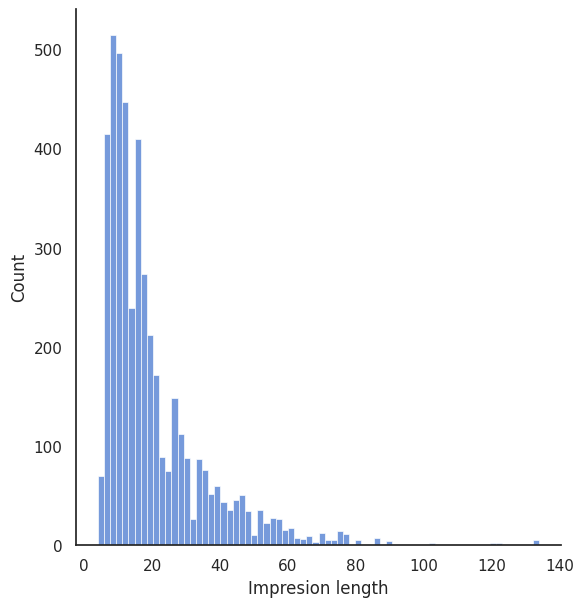


Value Counts for caption length top 5 values

Length|Counts
11    263
9     261
7     255
8     254
14    239
Name: count, dtype: int64

The max and min value of "caption length" was found to be 134 and 4 respectively
The 80 percentile value of caption_len which is 28 will be taken as the maximum padded value for each impression


In [ ]:
#tokenizer
tokenizer = Tokenizer(filters = '',oov_token = '<unk>') #setting filters to none
tokenizer.fit_on_texts(train.impression_final.values)
train_captions = tokenizer.texts_to_sequences(train.impression_final)
test_captions = tokenizer.texts_to_sequences(test.impression_final)
vocab_size = len(tokenizer.word_index)
caption_len = np.array([len(i) for i in train_captions])
start_index = tokenizer.word_index['<cls>'] #tokened value of <cls>
end_index = tokenizer.word_index['<end>'] #tokened value of <end>


#visualising impression length and other details
ax = sns.displot(caption_len,height = 6)
ax.set_titles('Value Counts vs Caption Length')
ax.set_xlabels('Impresion length')
plt.show()
print('\nValue Counts for caption length top 5 values\n')
print('Length|Counts')
print(pd.Series(caption_len).value_counts()[:5])
print('\nThe max and min value of "caption length" was found to be %i and %i respectively'%(max(caption_len),min(caption_len)))
print('The 80 percentile value of caption_len which is %i will be taken as the maximum padded value for each impression'%(np.percentile(caption_len,80)))
max_pad = int(np.percentile(caption_len,80))
del train_captions,test_captions #we will create tokenizing  and padding in-built in dataloader

In [ ]:
batch_size = 100
embedding_dim = 300
dense_dim = 512
lstm_units = dense_dim
dropout_rate = 0.2

In [ ]:
class Dataset():
  #here we will get the images converted to vector form and the corresponding captions
  def __init__(self,df,input_size,tokenizer = tokenizer, augmentation = True,max_pad = max_pad):
    """
    df  = dataframe containing image_1,image_2 and impression
    """
    self.image1 = df.image_1
    self.image2 = df.image_2
    self.caption = df.impression_ip #inp
    self.caption1 = df.impression_op  #output
    self.input_size = input_size #tuple ex: (512,512)
    self.tokenizer = tokenizer
    self.augmentation = augmentation
    self.max_pad = max_pad

    #image augmentation
    #https://imgaug.readthedocs.io/en/latest/source/overview/flip.html?highlight=Fliplr
    self.aug1 = iaa.Fliplr(1) #flip images horizaontally
    self.aug2 = iaa.Flipud(1) #flip images vertically


  def __getitem__(self,i):
    #gets the datapoint at i th index, we will extract the feature vectors of images after resizing the image  and apply augmentation
    image1 = cv2.imread(self.image1[i],cv2.IMREAD_UNCHANGED)/255
    image2 = cv2.imread(self.image2[i],cv2.IMREAD_UNCHANGED)/255 #here there are 3 channels
    image1 = cv2.resize(image1,self.input_size,interpolation = cv2.INTER_NEAREST)
    image2 = cv2.resize(image2,self.input_size,interpolation = cv2.INTER_NEAREST)
    if image1.any()==None:
      print("%i , %s image sent null value"%(i,self.image1[i]))
    if image2.any()==None:
      print("%i , %s image sent null value"%(i,self.image2[i]))


    #tokenizing and padding
    caption = self.tokenizer.texts_to_sequences(self.caption[i:i+1]) #the input should be an array for tokenizer ie [self.caption[i]]

    caption = pad_sequences(caption,maxlen = self.max_pad,padding = 'post') #opshape:(input_length,)
    caption = tf.squeeze(caption,axis=0) #opshape = (input_length,) removing unwanted axis if present

    caption1 = self.tokenizer.texts_to_sequences(self.caption1[i:i+1]) #the input should be an array for tokenizer ie [self.caption[i]]

    caption1 = pad_sequences(caption1,maxlen = self.max_pad,padding = 'post') #opshape: (input_length,)
    caption1 = tf.squeeze(caption1,axis=0) #opshape = (input_length,) removing unwanted axis if present




    if self.augmentation: #we will not apply augmentation that crops the image
          a = np.random.uniform()
          if a<0.333:
              image1 = self.aug1.augment_image(image1)
              image2 = self.aug1.augment_image(image2)
          elif a<0.667:
              image1 = self.aug2.augment_image(image1)
              image2 = self.aug2.augment_image(image2)
          else: #applying no augmentation
            pass;


    return image1,image2,caption,caption1


  def __len__(self):
    return len(self.image1)


class Dataloader(tf.keras.utils.Sequence):     #for batching
    def __init__(self, dataset, batch_size=1, shuffle=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.dataset))

    def __getitem__(self, i):

        # collect batch data
        start = i * self.batch_size
        stop = (i + 1) * self.batch_size
        indexes = [self.indexes[j] for j in range(start,stop)] #getting the shuffled index values
        data = [self.dataset[j] for j in indexes] #taken from Data class (calls __getitem__ of Data) here the shape is batch_size*3, (image_1,image_2,caption)

        batch = [np.stack(samples, axis=0) for samples in zip(*data)] #here the shape will become batch_size*input_size(of image)*3,batch_size*input_size(of image)*3
                                                                      #,batch_size*1*max_pad


        return tuple([[batch[0],batch[1],batch[2]],batch[3]]) #here [image1,image2, caption(without <END>)],caption(without <CLS>) (op)

    def __len__(self): #returns total number of batches in an epoch
        return len(self.indexes) // self.batch_size

    def on_epoch_end(self): #it runs at the end of epoch
        if self.shuffle:
            np.random.shuffle(self.indexes) #in-place shuffling takes place

In [ ]:
input_size = (224,224)
train_dataloader = Dataset(train,input_size)
train_dataloader = Dataloader(train_dataloader,batch_size = batch_size)

test_dataloader = Dataset(test,input_size)
test_dataloader = Dataloader(test_dataloader,batch_size = batch_size)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

def create_efficientnet(input_shape=(224, 224, 3), num_classes=14):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    base_model.trainable = False

    return model

model = create_efficientnet()




In [ ]:
efficientnet = create_efficientnet()
efficientnet.trainable = False

tf.keras.utils.plot_model(
    efficientnet,
    to_file="model_1.png",
    show_shapes=True,
)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [ ]:
del model

In [ ]:
class Image_encoder(tf.keras.layers.Layer):
  """
  This layer will output image backbone features after passing it through efficientnet
  here efficientnet will be not be trainable
  """
  def __init__(self,
               name = "image_encoder_block"
               ):
    super().__init__()
    self.efficientnet = create_efficientnet()
    self.efficientnet.trainable = False

  @tf.function
  def call(self,data):
    op = self.efficientnet(data)
    return op

In [ ]:
embedding_dim = 300
dense_dim = 512
lstm_units = dense_dim
dropout_rate = 0.2


glove = {}
with open('/content/drive/MyDrive/Radiography/glove.6B.300d.txt',encoding='utf-8') as f: #taking 300 dimesions
  for line in f:
    word = line.split() #it is stored as string like this "'the': '.418 0.24968 -0.41242 0.1217 0.34527 -0.044457 -0.4"
    glove[word[0]] = np.asarray(word[1:], dtype='float32')


embedding_dim = 300
# create a weight matrix for words in training docs for embedding purpose
embedding_matrix = np.zeros((vocab_size+1, embedding_dim)) #https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding

for word, i in tokenizer.word_index.items():
  embedding_vector = glove.get(word)
  if embedding_vector is not None: #if the word is found in glove vectors
      embedding_matrix[i] = embedding_vector[:embedding_dim]

In [ ]:
tf.keras.backend.clear_session()
image1 = Input(shape = (input_size + (3,))) #shape = 224,224,3
image2 = Input(shape = (input_size + (3,))) #https://www.w3resource.com/python-exercises/tuple/python-tuple-exercise-5.php
caption = Input(shape = (max_pad,))


from tensorflow.keras.layers import Layer

class ExpandDimsLayer(Layer):
    def __init__(self, axis, **kwargs):
        super(ExpandDimsLayer, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)


img_encoder = Image_encoder() #contains inceptionv3 model which is set trainable  =  False
# img2_encoder = Image_encoder() #opshape: (?,1024)
bk_feat1 = img_encoder(image1)
# bk_dense = Dense(dense_dim,
#                  activation = 'relu',
#                  name = 'bk_dense'
#                   )
# bk_feat1 = bk_dense(bk_feat1) #dense for the first image op: (?,dense_dim)

bk_feat2 = img_encoder(image2)
# bk_feat2 = bk_dense(bk_feat2) #dense for the 2nd image op: (?,dense_dim)

bk_features_concat = Concatenate(axis=-1)([bk_feat1,bk_feat2]) #concatenating the backbone images op_shape: (?,1024)
# bk_features_concat = BatchNormalization()(bk_features_concat) #applying batch norm
# bk_features_concat = Dropout(dropout_rate)(bk_features_concat)
image_dense = Dense(dense_dim,
                    activation = 'relu',
                    name = 'Image_dense',
                    use_bias='False'

                    )


image_bkbone = image_dense(bk_features_concat) #final op from dense op_shape: (?,dense_dim) this will be added as initial states to the lstm
# Replace the tf.keras.backend.expand_dims call with the custom layer
image_dense_op = ExpandDimsLayer(axis=1)(image_bkbone) # op_shape: (?,1,dense_dim)




embedding = Embedding(input_dim  = vocab_size+1,
                              output_dim = embedding_dim,
                              input_length = max_pad,
                              mask_zero = True,
                              weights = [embedding_matrix],
                              name = 'embedding'
                              )
embed_op = embedding(caption) #op_shape: (?,input_length,embedding_dim)






lstm_layer = LSTM(units = lstm_units,
                  return_sequences= True,
                  return_state = True
                  )
lstm_op,lstm_h,lstm_c = lstm_layer(embed_op,initial_state = [image_bkbone,image_bkbone]) #op_shape = batch_size*input_length*lstm_units

# lstm_op = BatchNormalization()(lstm_op)
add = Add()([image_dense_op,lstm_op]) #op_shape: (?,input_lenght,lstm_units/dense_dim) here lstm_dims=dense_dim

op_dense = Dense(vocab_size+1,
                 activation = 'softmax',
                 name = 'output_dense'
                 ) #op: (?,input_length,vocab_size+1)

output = op_dense(add)

model = tf.keras.Model(inputs = [image1,image2,caption], outputs = output)

In [ ]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 image_encoder (Image_encod  (None, 14)                   4719793   ['input_1[0][0]',             
 er)                                                                 'input_2[0][0]']             
                                                                                                  
 concatenate (Concatenate)   (None, 28)                   0         ['image_encoder[0][0]', 

In [ ]:
loss_func = tf.keras.losses.SparseCategoricalCrossentropy()

def custom_loss(y_true, y_pred):
    #getting mask value to not consider those words which are not present in the true caption
    mask = tf.math.logical_not(tf.math.equal(y_true, 0))

    #y_pred = y_pred+10**-7 #to prevent loss becoming null

    #calculating the loss
    loss_ = loss_func(y_true, y_pred)

    #converting mask dtype to loss_ dtype
    mask = tf.cast(mask, dtype=loss_.dtype)

    #applying the mask to loss
    loss_ = loss_*mask

    #returning mean over all the values
    return tf.reduce_mean(loss_)

lr = 10**-3
optimizer = tf.keras.optimizers.Adam(learning_rate = lr)
model.compile(optimizer=optimizer,loss=custom_loss,metrics= ['accuracy'])

In [ ]:
tf.keras.backend.clear_session()
# Define paths for saving logs and model weights
tb_filename = 'Image_Encoder_Decoder_efficient/'
tb_file = os.path.join('/content/drive/MyDrive/Radiography', tb_filename)
model_filename = 'Image_Encoder_Decoder_efficient.weights.h5'
model_save = os.path.join('/content/drive/MyDrive/Radiography', model_filename)
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience = 5,
                                     verbose = 2
                                     ),
    tf.keras.callbacks.ModelCheckpoint(filepath=model_save,
                                       save_best_only = True,
                                      save_weights_only = True,
                                       verbose = 2
                                       ),
    tf.keras.callbacks.TensorBoard(histogram_freq=1,
                                   log_dir=tb_file),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                              patience=2, min_lr=10**-7, verbose = 2)

] #from keras documentation

In [ ]:
!rm -r '/content/drive/MyDrive/Radiography/Image_Encoder_Decoder_efficient/'

rm: cannot remove '/content/drive/MyDrive/Radiography/Image_Encoder_Decoder_efficient/': No such file or directory


In [ ]:
model.fit(train_dataloader,
          validation_data = test_dataloader,
          epochs = 15,
          callbacks = my_callbacks
          )

Epoch 1/15
45/45 [==============================] - ETA: 0s - loss: 3.6106 - accuracy: 0.1825 
Epoch 1: val_loss improved from inf to 2.51021, saving model to /content/drive/MyDrive/Radiography/Image_Encoder_Decoder_efficient.weights.h5
45/45 [==============================] - 1142s 24s/step - loss: 3.6106 - accuracy: 0.1825 - val_loss: 2.5102 - val_accuracy: 0.3485 - lr: 0.0010
Epoch 2/15
45/45 [==============================] - ETA: 0s - loss: 2.9325 - accuracy: 0.3121
Epoch 2: val_loss improved from 2.51021 to 2.30414, saving model to /content/drive/MyDrive/Radiography/Image_Encoder_Decoder_efficient.weights.h5
45/45 [==============================] - 239s 5s/step - loss: 2.9325 - accuracy: 0.3121 - val_loss: 2.3041 - val_accuracy: 0.3953 - lr: 0.0010
Epoch 3/15
45/45 [==============================] - ETA: 0s - loss: 2.5697 - accuracy: 0.3779
Epoch 3: val_loss improved from 2.30414 to 2.20069, saving model to /content/drive/MyDrive/Radiography/Image_Encoder_Decoder_efficient.weight

In [ ]:
model_filename = 'Image_Encoder_Decoder_efficient.weights.h5'
model_save = os.path.join('/content/drive/MyDrive/Radiography', model_filename)
model1 = tf.keras.Model(inputs = [image1,image2,caption], outputs = output)
model1.load_weights(model_save)

In [ ]:
def get_bleu(reference,prediction):
  """
  Given a reference and prediction string, outputs the 1-gram,2-gram,3-gram and 4-gram bleu scores
  """
  reference = [reference.split()] #should be in an array (cos of multiple references can be there here only 1)
  prediction = prediction.split()
  bleu1 = sentence_bleu(reference,prediction,weights = (1,0,0,0),)
  bleu2 = sentence_bleu(reference,prediction,weights = (0.5,0.5,0,0))
  bleu3 = sentence_bleu(reference,prediction,weights = (0.33,0.33,0.33,0))
  bleu4 = sentence_bleu(reference,prediction,weights = (0.25,0.25,0.25,0.25))

  return bleu1,bleu2,bleu3,bleu4

In [ ]:
#calculate bleu scores for every datapoint
def mean_bleu(test,predict,model=model1,**kwargs):
  """
  given a df and predict fucntion which predicts the impression of the caption
  outpus the mean bleu1,bleu2,bleu3, bleu4 for entire datapoints in df
  """
  if kwargs!=None:
    top_k = kwargs.get('top_k')
  else:
    top_k = None
  bleu1,bleu2,bleu3,bleu4 = [],[],[],[]
  for index,data in test.iterrows():
    if top_k==None:
      predict_val = predict(data['image_1'],data['image_2'],model = model) #predicted sentence
    else:
      predict_val = predict(data['image_1'],data['image_2'],model = model,top_k = top_k)
    true = data.impression
    _ = get_bleu(true,predict_val)
    bleu1.append(_[0])
    bleu2.append(_[1])
    bleu3.append(_[2])
    bleu4.append(_[3])
  return np.array(bleu1).mean(),np.array(bleu2).mean(),np.array(bleu3).mean(),np.array(bleu4).mean()

In [ ]:
def greedy_search_predict(image1,image2,model = model1):
  """
  Given paths to two x-ray images predicts the impression part of the x-ray in a greedy search algorithm
  """
  image1 = cv2.imread(image1,cv2.IMREAD_UNCHANGED)/255
  image2 = cv2.imread(image2,cv2.IMREAD_UNCHANGED)/255
  image1 = tf.expand_dims(cv2.resize(image1,input_size,interpolation = cv2.INTER_NEAREST),axis=0) #introduce batch and resize
  image2 = tf.expand_dims(cv2.resize(image2,input_size,interpolation = cv2.INTER_NEAREST),axis=0)


  image1 = model.get_layer('image_encoder')(image1) #output from chexnet
  image2 = model.get_layer('image_encoder')(image2)

  # image1 = model.get_layer('bk_dense')(image1) #op from dense layer
  # image2 = model.get_layer('bk_dense')(image2)

  concat = model.get_layer('concatenate')([image1,image2])
  image_dense = model.get_layer('Image_dense')(concat)
  # concat = model.get_layer('batch_normalization')(concat)
  # image_dense = model.get_layer('Image_dense')(concat)
  bk_feat = tf.keras.backend.expand_dims(image_dense,axis=1)


  states = [image_dense, image_dense]
  a = []
  pred = []
  for i in range(max_pad):
    if i==0: #if first word
      caption = np.array(tokenizer.texts_to_sequences(['<cls>'])) #shape: (1,1)
    caption= model.get_layer('embedding')(caption) #embedding shape = 1*1*300
    caption,state_h,state_c = model.get_layer('lstm')(caption,initial_state = states) #lstm 1*1*512
    states = [state_h,state_c]

    add = model.get_layer('add')([bk_feat,caption]) #add
    output = model.get_layer('output_dense')(add) #1*1*vocab_size (here batch_size=1)

    #prediction
    max_prob = tf.argmax(output,axis=-1) #tf.Tensor of shape = (1,1)
    caption = np.array(max_prob) #will be sent to embedding for next iteration
    if max_prob==np.squeeze(tokenizer.texts_to_sequences(['<end>'])):
      break;
    else:
      a.append(tf.squeeze(max_prob).numpy())
  return tokenizer.sequences_to_texts([a])[0] #here output would be 1,1 so subscripting to open the array

In [ ]:
%%time
k=-1
image1,image2 = test['image_1'].iloc[k],test['image_2'].iloc[k]
print(greedy_search_predict(image1,image2,model=model))

no acute cardiopulmonary abnormality .
CPU times: user 486 ms, sys: 123 ms, total: 609 ms
Wall time: 201 ms


In [ ]:

%%time
_ = mean_bleu(test,greedy_search_predict)

CPU times: user 4min 5s, sys: 1min 5s, total: 5min 10s
Wall time: 1min 30s


In [ ]:

k = list(_)
index = 'greedy search'
result = pd.DataFrame([k],columns = ["bleu1","bleu2","bleu3","bleu4"],index = [index])

In [ ]:
result

,bleu1,bleu2,bleu3,bleu4
greedy search,0.311702,0.212618,0.144814,0.085969


In [ ]:
#beam search
def encoder_op(image1,image2,model = model1):
  """
  Given image1 and image2 filepath, outputs
  their backbone features which will be input
  to the decoder
  """
  image1 = cv2.imread(image1,cv2.IMREAD_UNCHANGED)/255
  image2 = cv2.imread(image2,cv2.IMREAD_UNCHANGED)/255

  image1 = tf.expand_dims(cv2.resize(image1,input_size,interpolation = cv2.INTER_NEAREST),axis=0) #introduce batch and resize
  image2 = tf.expand_dims(cv2.resize(image2,input_size,interpolation = cv2.INTER_NEAREST),axis=0)

  image1 = model.get_layer('image_encoder')(image1) #output from chexnet
  image2 = model.get_layer('image_encoder')(image2)

  concat = model.get_layer('concatenate')([image1,image2])
  image_dense = model.get_layer('Image_dense')(concat)
  bk_feat = tf.keras.backend.expand_dims(image_dense,axis=1)
  states = [image_dense, image_dense]
  return bk_feat,states


In [ ]:
def beam_search_predict(image1, image2, top_k=3, max_pad=max_pad, model=model1):
    """
    Given image1, image2 get the top beam search predicted sentence.
    """
    k = top_k
    cls_token = tokenizer.texts_to_sequences(['<start>'])[0]  # Assuming <start> is the start token

    bk_feat, states = encoder_op(image1, image2)
    seq_score = [[cls_token, 0, states]]  # [[[<start>], 0]]
    finished_seq_score = []

    for i in range(max_pad):  # traverse through all lengths
        all_candidates = []  # stores all the top k seq along with their scores
        new_seq_score = []  # stores the seq_score which does not have <end> in them

        for s in seq_score:  # traverse for all top k sequences
            if len(s[0]) == 0:
                print("Encountered an empty sequence in seq_score.")
                continue

            text_input = s[0][-1]  # getting the last predicted output
            states = s[2]
            caption = model.get_layer('embedding')(np.array([[text_input]]))  # ip must be in shape (batch_size, seq length, dim)
            caption, state_h, state_c = model.get_layer('lstm')(caption, initial_state=states)
            states = [state_h, state_c]
            add = model.get_layer('add')([bk_feat, caption])
            output = model.get_layer('output_dense')(add)[0][0]  # (vocab_size,)
            top_words = tf.argsort(output, direction='DESCENDING')[:k]  # get the top k words

            seq, score, _ = s
            for t in top_words.numpy():
                # updating the score and seq
                candidates = [seq + [t], score - np.log(output[t].numpy()), states]
                all_candidates.append(candidates)

        seq_score = sorted(all_candidates, key=lambda l: l[1])[:k]  # getting the top 3 sentences with high prob ie low score

        # Check for maximum sequence length or punctuation
        for seq, score, state in seq_score:
            if len(seq) >= max_pad or tokenizer.sequences_to_texts([seq])[-1] in ['.', '?', '!']:  # Assuming punctuation marks end sentences
                finished_seq_score.append([seq, score])
            else:
                new_seq_score.append([seq, score, state])

        seq_score = new_seq_score

        if not seq_score:  # if null array
            break

    if not finished_seq_score:
        print("No finished sequences found.")
        return ""

    seq_score = finished_seq_score[-1]
    sentence = seq_score[0][1:]  # here <start> is not considered
    score = seq_score[1]

    # Post-process to remove <end> tokens
    words = tokenizer.sequences_to_texts([sentence])[0].split()
    filtered_words = [word for word in words if word != '<end>']
    filtered_sentence = ' '.join(filtered_words)

    return filtered_sentence




In [ ]:
%%time
k=-1
image1,image2 = test['image_1'].iloc[k],test['image_2'].iloc[k]
print(beam_search_predict(image1,image2,top_k = 3))

low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe
CPU times: user 1.58 s, sys: 411 ms, total: 1.99 s
Wall time: 1.14 s


In [ ]:
%%time
k=-1
image1,image2 = test['image_1'].iloc[k],test['image_2'].iloc[k]
print(beam_search_predict(image1,image2,top_k = 5))

low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . of the thoracic spine . .
CPU times: user 2.43 s, sys: 521 ms, total: 2.95 s
Wall time: 1.81 s


In [ ]:
%%time
_ = mean_bleu(test,beam_search_predict)

CPU times: user 14min 27s, sys: 3min 4s, total: 17min 31s
Wall time: 9min 59s


In [ ]:
import pandas as pd

k = list(_)
index = 'beam search (top_k = 3)'
temp = pd.DataFrame([k],columns = ["bleu1","bleu2","bleu3","bleu4"],index = [index])
result = pd.concat([result,temp])
result

,bleu1,bleu2,bleu3,bleu4
greedy search,0.311702,0.212618,0.144814,0.085969
beam search (top_k = 3),0.311702,0.212618,0.144814,0.085969
beam search (top_k = 3),0.158702,0.066346,0.027017,0.015779


In [ ]:
%%time
test['bleu_1_gs'] = np.zeros(test.shape[0]) #greedy search
test['bleu_1_bm'] = np.zeros(test.shape[0]) #beam search
test['prediction_gs'] = np.zeros(test.shape[0]) #greedy search
test['prediction_bm'] = np.zeros(test.shape[0]) #beam search
for index,rows in test.iterrows():
  #greedy search
  predicted_text = greedy_search_predict(rows.image_1,rows.image_2,model1)
  test.loc[index,'prediction_gs'] = predicted_text
  reference = [rows['impression'].split()]
  test.loc[index,'bleu_1_gs'] = sentence_bleu(reference,predicted_text.split(),weights = (1,0,0,0))

  #beam search
  predicted_text = beam_search_predict(rows.image_1,rows.image_2,top_k = 3,model = model1)
  test.loc[index,'prediction_bm'] = predicted_text
  test.loc[index,'bleu_1_bm'] = sentence_bleu(reference,predicted_text.split(),weights = (1,0,0,0))



test['prediction_gs'].value_counts()*100/test.shape[0] #greedy search





CPU times: user 18min 33s, sys: 4min 8s, total: 22min 42s
Wall time: 11min 30s


,count
prediction_bm,
low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe,100.0


In [ ]:
test['prediction_bm'].value_counts()*100/test.shape[0] #beam search

In [ ]:
# Random predictions on test data
def final_caption_pred(image1,image2,method = "beam",top_k = 3,model=model1):
  """
  Given image1. image2 paths, the model, top_k and the method of prediction returns the predicted caption
  method: "greedy" or "g" for greedy search, "beam" or "b" for beam search
  """
  if method in ['greedy','g']:
    pred_caption = greedy_search_predict(image1,image2,model)
  elif method in ['beam','b']:
    pred_caption = beam_search_predict(image1,image2,top_k = top_k,model = model)
  else:
    print("Enter 'b' or 'beam' for beam search and 'g' or 'greedy' for greedy search")

  return pred_caption


def inference(image1,image2,true_caption,model=model1,top_k = [3],image_size = (10,20)):
  """
  given 2 images (their paths), the true caption, the model and the range of top_k
  prints the two images, true caption along with greedy search prediction and beam search prediction of top_k range
  """
  image1_array = cv2.imread(image1,cv2.IMREAD_UNCHANGED)
  image2_array = cv2.imread(image2,cv2.IMREAD_UNCHANGED)
  if type(top_k)==int:
    top_k = [top_k] #changing it to list if top_k given is of int type
  greedy_caption = final_caption_pred(image1,image2,method='g',model=model) #getting the greedy search prediction

  #printing the 2 images
  plt.figure(figsize = image_size)
  plt.subplot(121)
  plt.imshow(image1_array)
  plt.axis("off")

  plt.subplot(122)
  plt.imshow(image2_array)
  plt.axis("off")
  plt.show()

  print("\nTrue caption: '%s'"%(true_caption))
  print("Predicted caption(greedy search): '%s'"%(greedy_caption))
  #beam search of top_k
  if top_k != None:
    for i in top_k:
      beam_caption = final_caption_pred(image1,image2,method='b',model=model,top_k = i)
      print("Predicted caption(beam search = %i): '%s'"%(i,beam_caption))

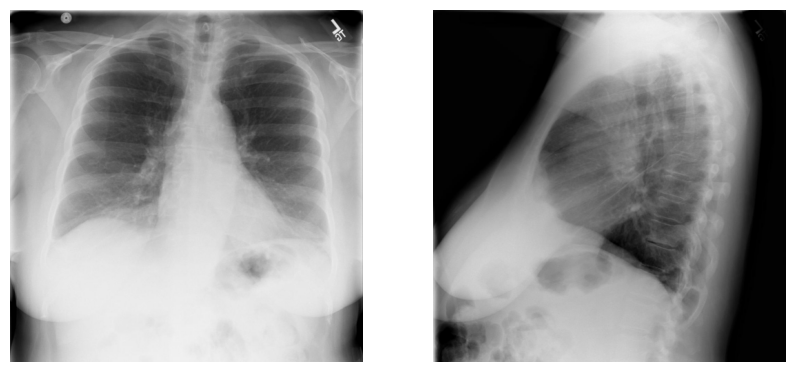


True caption: 'no acute cardiopulmonary abnormality .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


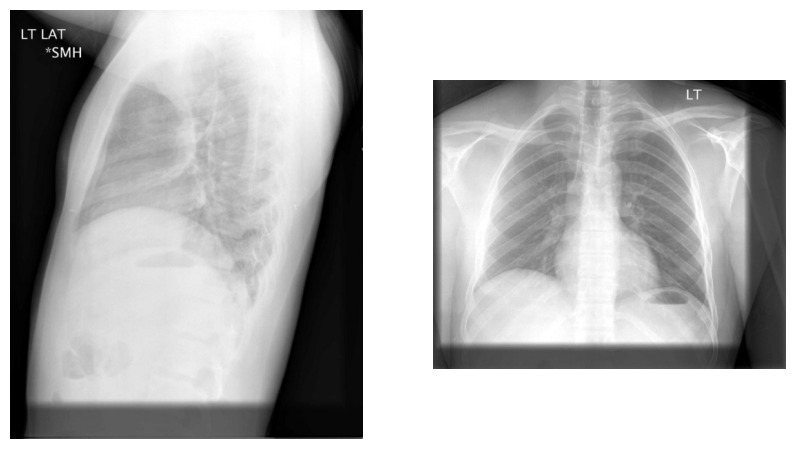


True caption: 'no acute cardiopulmonary abnormality . .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


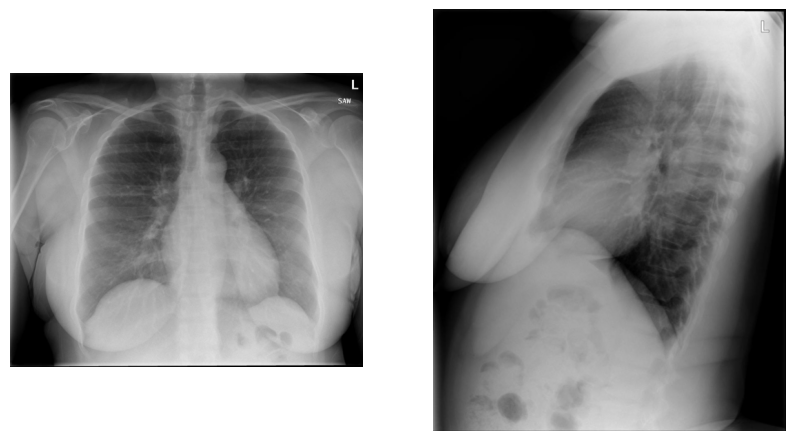


True caption: 'no acute cardiopulmonary abnormality . .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


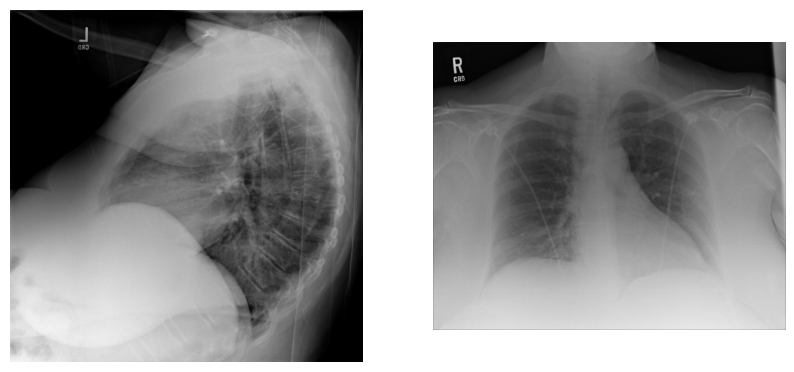


True caption: 'no acute cardiopulmonary abnormality .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


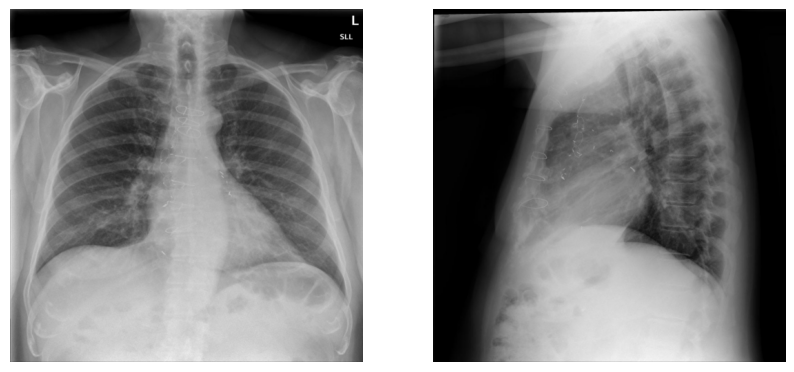


True caption: 'no acute cardiopulmonary abnormality .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


In [ ]:
# Correct captions

# Get the indices where 'bleu_1_gs' > 0.8
indices = test[test['bleu_1_gs'] > 0.8].index

# Determine the sample size
sample_size = min(5, len(indices))

# Sample the indices
sampled_indices = indices.to_series().sample(sample_size).index

# Process the sampled indices
for k in sampled_indices:
    image1, image2 = test['image_1'][k], test['image_2'][k]
    true_caption = test['impression'][k]
    inference(image1, image2, true_caption)

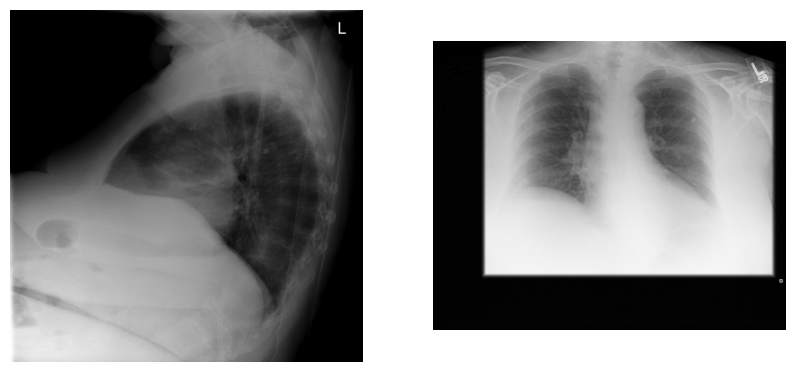


True caption: 'no acute or active cardiac pulmonary or pleural disease .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


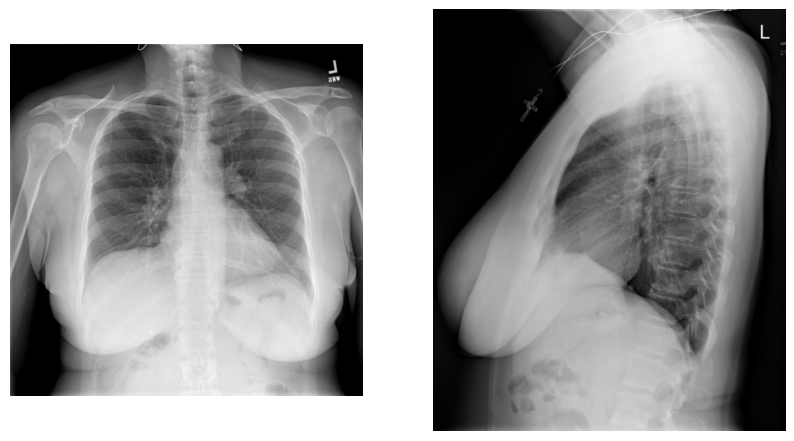


True caption: 'normal chest .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


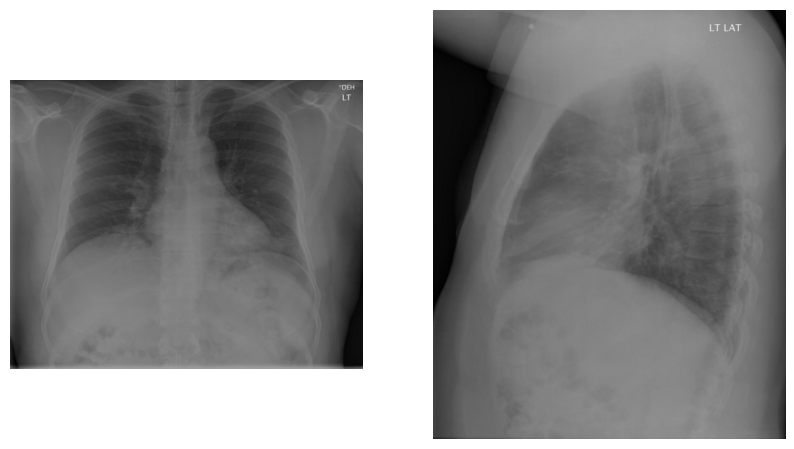


True caption: 'there is a left basilar airspace opacity which is concerning for pneumonia . right basilar atelectasis .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


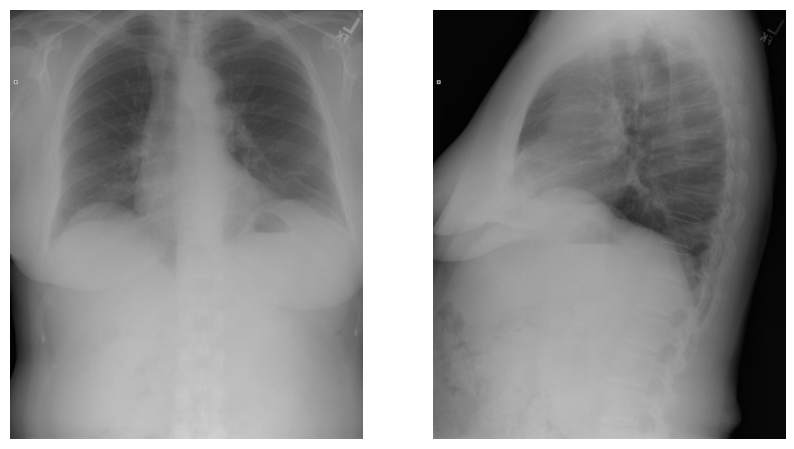


True caption: 'no evidence of pulmonary tuberculosis . low lung volumes with minimal streaky basilar airspace disease atelectasis . right paratracheal prominence represents tortuous . comparison with prior imaging studies could confirm this if available . .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


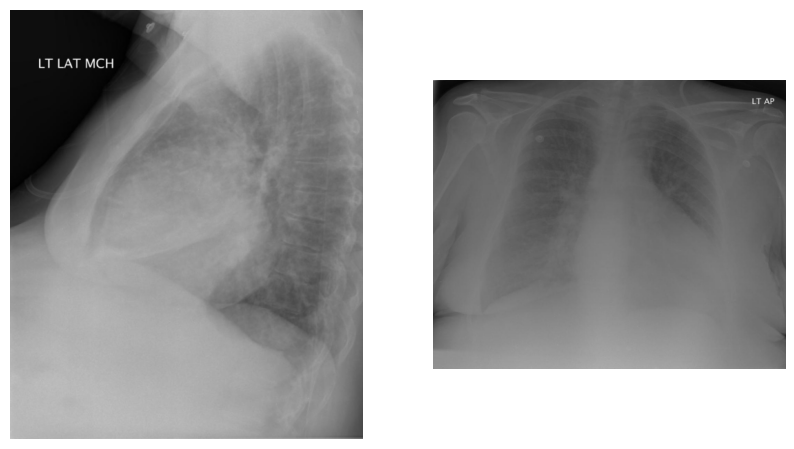


True caption: 'cardiomegaly with pulmonary edema superimposed on chronic interstitial lung changes .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'
Predicted caption(beam search = 3): 'low lung volumes with bronchovascular crowding without acute cardiopulmonary abnormality . of the thoracic spine . . of the left upper lobe'


In [ ]:
# incorret caption

i = test[test['bleu_1_gs']<0.3].sample(5).index
for k in i:
  image1,image2 = test['image_1'][k],test['image_2'][k]
  true_caption = test['impression'][k]
  inference(image1,image2,true_caption)


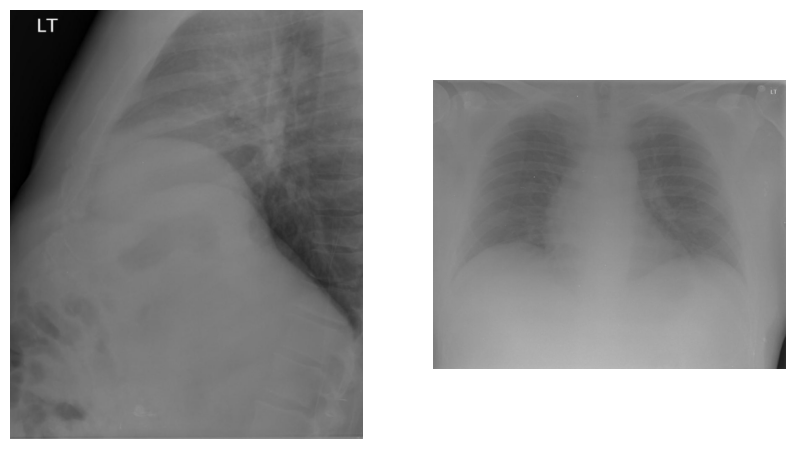


True caption: 'low lung volumes without acute cardiopulmonary abnormality .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'


In [ ]:
# comparing the train

k = 100
image1,image2 = train['image_1'][k],train['image_2'][k]
true_caption = train['impression'][k]
inference(image1,image2,true_caption,top_k = None)

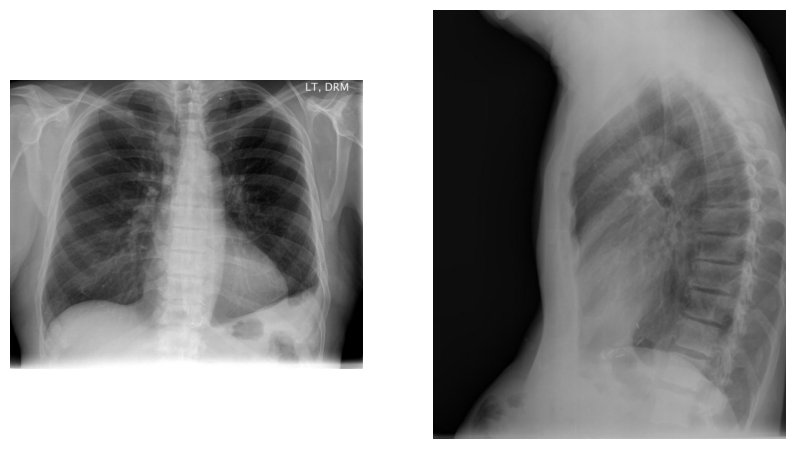


True caption: 'heart size is normal . scattered right hilar granulomas and calcified mm right apical granuloma . resolution of right effusion and infiltrate . stable chronic blunting of the lateral left costophrenic .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'


In [ ]:

k = 1000
image1,image2 = train['image_1'][k],train['image_2'][k]
true_caption = train['impression'][k]
inference(image1,image2,true_caption,top_k = None)

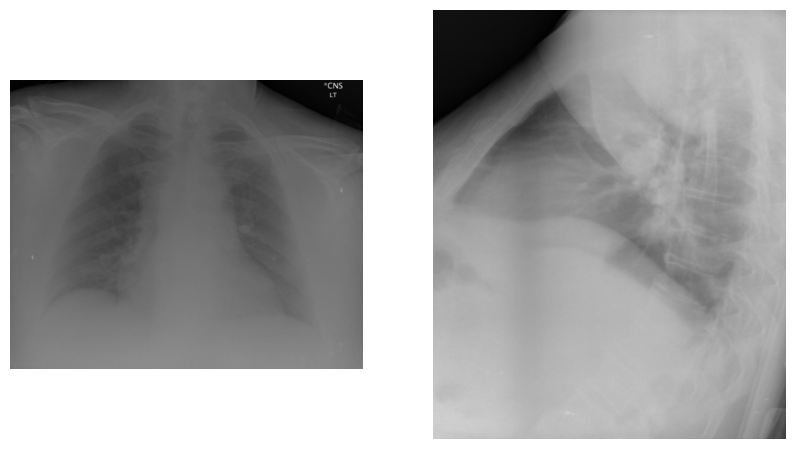


True caption: 'cardiomegaly without acute cardiopulmonary abnormality .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'


In [ ]:

k = 4000
image1,image2 = train['image_1'][k],train['image_2'][k]
true_caption = train['impression'][k]
inference(image1,image2,true_caption,top_k = None)

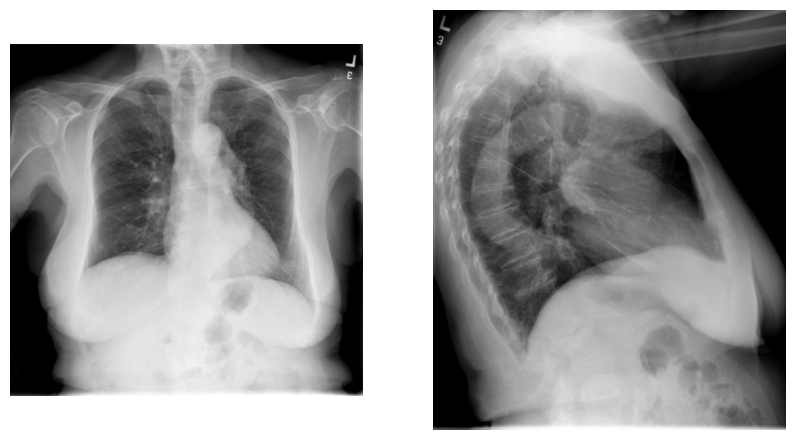


True caption: 'no acute process .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'


In [ ]:
# comparing the test

k = 160
image1,image2 = test['image_1'][k],test['image_2'][k]
true_caption = test['impression'][k]
inference(image1,image2,true_caption,top_k = None)

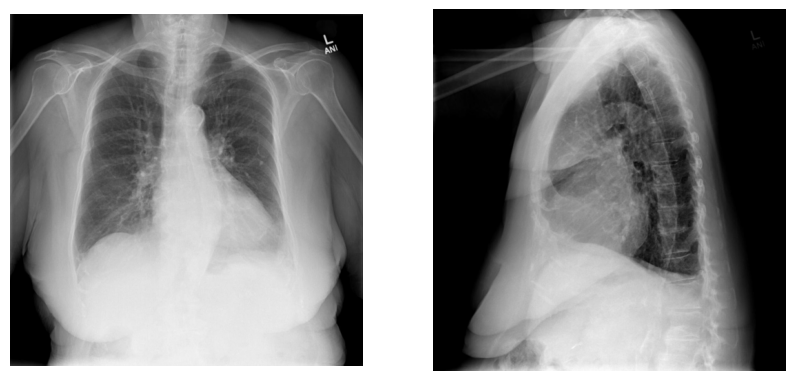


True caption: 'cardiomegaly without acute disease .'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'


In [ ]:

k = 290
image1,image2 = test['image_1'][k],test['image_2'][k]
true_caption = test['impression'][k]
inference(image1,image2,true_caption,top_k = None)

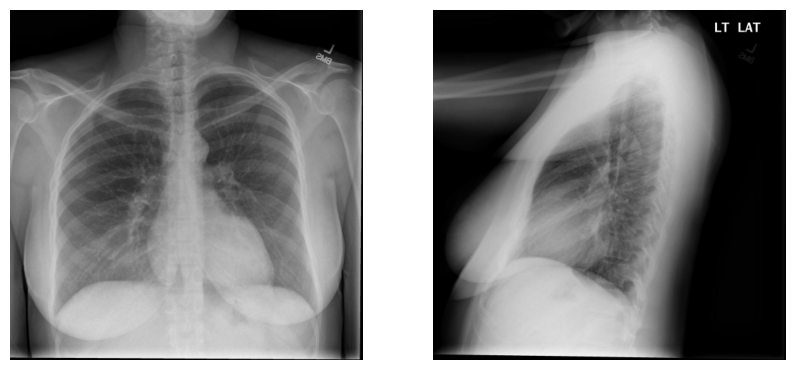


True caption: 'no radiographic evidence of acute cardiopulmonary disease'
Predicted caption(greedy search): 'no acute cardiopulmonary abnormality .'


In [ ]:

k = 25
image1,image2 = test['image_1'][k],test['image_2'][k]
true_caption = test['impression'][k]
inference(image1,image2,true_caption,top_k = None)

In [ ]:
# final result
result

,bleu1,bleu2,bleu3,bleu4
greedy search,0.311702,0.212618,0.144814,0.085969
beam search (top_k = 3),0.311702,0.212618,0.144814,0.085969
beam search (top_k = 3),0.158702,0.066346,0.027017,0.015779
